# 02 · Sales layer

Turns the world from `01_build_world` into **sales**. This is the step that decides *how advertising actually works* in this world - the "answer key" every method will later be scored against.

### What this step does, in plain terms

```
media spend ──► adstock ──► saturation ──► × β ──► media revenue ─┐
                (carryover)  (diminishing                         │
                              returns)                            ├─► expected revenue ─► PyMC draws orders ─► observed sales
baseline × growth × demand × promotions ──► organic revenue ──────┘
                                    │
             organic + media buyers ┴─► Google the brand ─► brand search clicks & spend
```

1. **Media effects** - for each channel: spend per head → *adstock* (today's ad still works for a few days) → *saturation* (the 10th £ does less than the 1st) → × β. β is chosen so each channel's average incremental ROAS exactly equals the value in `world.yaml`.
2. **Baseline** - what the brand would sell with zero ads: population × regional traits × growth × demand × promotions.
3. **Brand search (the mediator)** - people who saw ads (and people who'd buy anyway) Google the brand. So brand search spend *rises when other channels work*, even though brand search itself barely adds sales (true iROAS 0.3). This is why platforms over-credit it.
4. **Orders with PyMC** - a generative model of daily orders. We fix the true parameters with `pm.do` and sample with `pm.draw` (the approach from the PyMC Labs post). Noise is Negative Binomial, so small regions are noisy - just like real life.

**Why compute the media curves in numpy, not inside the PyMC model you'll fit later?** If the world is generated by exactly the model you fit, recovery is trivially perfect ("inverse crime"). Here TV uses a *delayed* adstock and regions respond differently - things the MMM won't assume.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, yaml, duckdb, pymc as pm
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.simulate import sales
from src.simulate.store import write_tables

plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e6", "grid.linewidth": 0.6, "lines.linewidth": 1.6})
COLORS = {"meta": "#2a78d6", "google_nonbrand": "#eb6834", "tiktok": "#1baf7a", "youtube_tv": "#eda100",
          "brand_search": "#e87ba4", "promotion": "#4a3aa7", "baseline": "#d9d8d0"}

cfg = yaml.safe_load((ROOT / "config/world.yaml").read_text())
rng = np.random.default_rng([cfg["seed"], 2])     # own stream for this step

# The simulator reads the CLEAN world from truth (this is the world-builder, not the analyst)
con = duckdb.connect(str(ROOT / "truth/truth.duckdb"), read_only=True)
regions = con.sql("select * from region_params").df()
demand  = con.sql("select * from demand_index").df()
promos  = con.sql("select * from promotions_truth").df()
media_daily = con.sql("select * from media_daily_clean where channel <> 'brand_search'").df()
national    = con.sql("select * from media_national_clean where channel <> 'brand_search'").df()
con.close()

## 1a. Adstock - how long an ad keeps working
Each curve shows what share of £1 spent today acts on day 0, 1, 2, … Half-life = days until the effect halves.

- Search dies within a day or two; Meta/TikTok linger ~a week.
- **TV is delayed**: the effect *builds* for ~5 days, then decays slowly. The MMM will assume plain geometric decay - a deliberate mismatch.

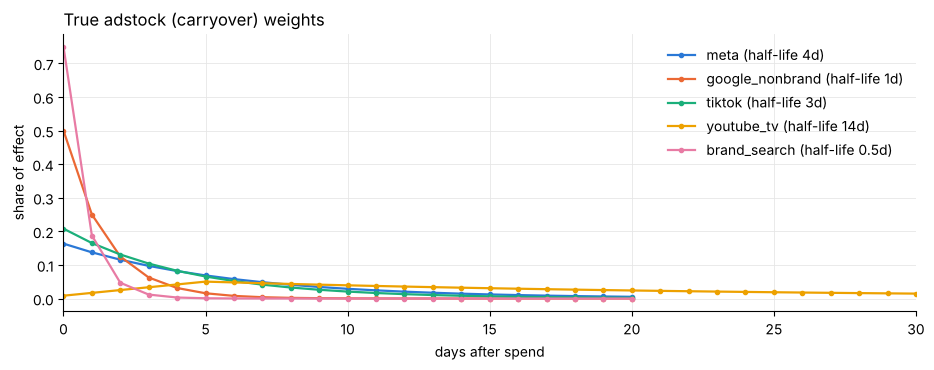

In [2]:
fig, ax = plt.subplots()
for ch, c in cfg["channels"].items():
    w = sales.adstock_weights(c["truth"], cfg["sales"]["adstock_l_max"])
    ax.plot(np.arange(len(w)), w, color=COLORS[ch], marker="o", ms=3, label=f"{ch} (half-life {c['truth']['half_life_days']}d)")
ax.set_xlim(0, 30); ax.set_xlabel("days after spend"); ax.set_ylabel("share of effect")
ax.set_title("True adstock (carryover) weights", loc="left"); ax.legend(frameon=False); plt.show()

## 1b. Saturation - diminishing returns
Hill curve: `effect = x^s / (x^s + K^s)`. `K` = spend level giving half the maximum effect; `s` = shape.
- `s = 1`: every extra £ does a bit less (concave).
- `s = 2` (TV): **S-curve** - too little spend does almost nothing; it needs a minimum weight to work.

x-axis is relative to the channel's average (adstocked) spend, so **1.0 = where the channel normally operates.**

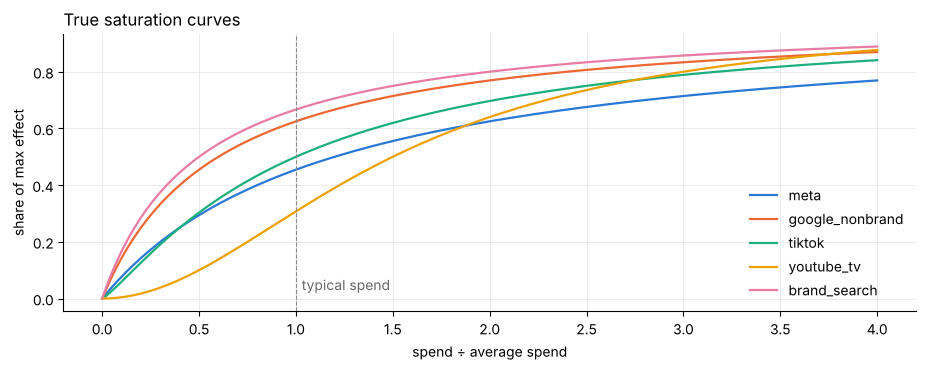

In [3]:
x = np.linspace(0, 4, 200)
fig, ax = plt.subplots()
for ch, c in cfg["channels"].items():
    t = c["truth"]
    ax.plot(x, sales.hill(x, t["saturation_half_spend_pct"], t["hill_shape"]), color=COLORS[ch], label=ch)
ax.axvline(1, color="#888", lw=0.8, ls="--"); ax.text(1.03, 0.03, "typical spend", color="#666")
ax.set_xlabel("spend ÷ average spend"); ax.set_ylabel("share of max effect")
ax.set_title("True saturation curves", loc="left"); ax.legend(frameon=False); plt.show()

## 2. The PyMC model (the generative story for orders)
`b0` = organic £ per head per day, `beta` = each channel's £ per head at full saturation, `nb_alpha` = noise. Priors are deliberately loose - see the prior predictive check below.

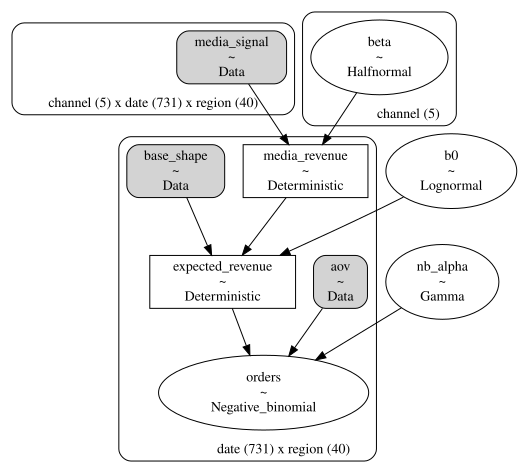

In [4]:
out = sales.simulate_sales(cfg, regions, demand, promos, media_daily, national, rng)
model = out["model"]
try:
    display(pm.model_to_graphviz(model))
except Exception as e:      # needs the graphviz system package (Mac: brew install graphviz)
    print(model)

### Prior predictive check
Before trusting a model, sample from its **priors** and ask: *does this produce plausible data?* The grey lines are worlds the priors allow; blue is the world we fixed with `pm.do`. You'll do this again on the MMM - it's how you catch silly priors before fitting.

> **This check caught a real mistake while building this notebook.** The first version used `beta ~ HalfNormal(0.05)`, and the prior draws came out ~10× too many orders - the prior allowed ads to sell far more than the whole baseline. Tightening to `HalfNormal(0.005)` fixed it. Same lesson applies to your MMM priors.

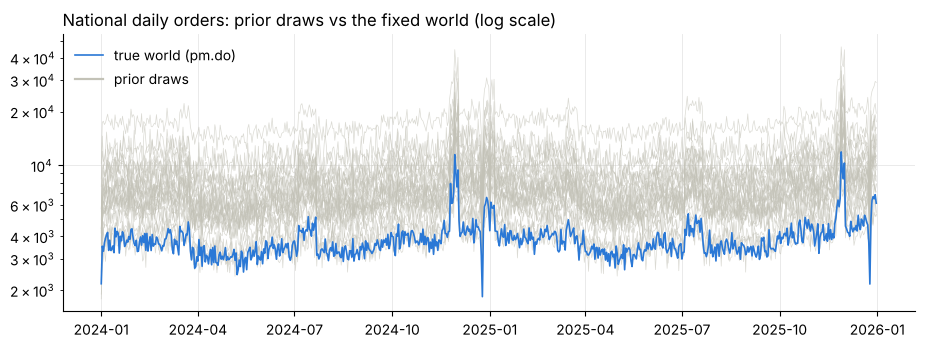

In [5]:
prior_orders = pm.draw(model["orders"], draws=30, random_seed=1)          # (draws, date, region)
nat_prior = prior_orders.sum(-1)
nat_true = out["sales_obs"].groupby("date")["orders"].sum()

fig, ax = plt.subplots()
for d in nat_prior: ax.plot(nat_true.index, d, color="#c3c2b7", lw=0.5, alpha=0.6)
ax.plot(nat_true.index, nat_true.values, color="#2a78d6", lw=1.2, label="true world (pm.do)")
ax.plot([], [], color="#c3c2b7", label="prior draws")
ax.set_yscale("log"); ax.set_title("National daily orders: prior draws vs the fixed world (log scale)", loc="left")
ax.legend(frameon=False); plt.show()

## 3. The answer key
`avg_iroas` = total incremental revenue ÷ total spend (matches `world.yaml` by construction).
`marginal_iroas` = revenue from the **next** £ (+1% spend). Where marginal < average, the channel is saturated; where marginal > average (TV, S-curve) it's under-invested. This is the number budget decisions should use.

In [6]:
ct = out["channel_truth"]
ct[["channel", "adstock", "half_life_days", "decay_alpha_daily", "hill_shape",
    "total_spend", "total_contribution", "target_iroas", "avg_iroas", "marginal_iroas"]].round(3)

,channel,adstock,half_life_days,decay_alpha_daily,hill_shape,total_spend,total_contribution,target_iroas,avg_iroas,marginal_iroas
0,meta,geometric,4.0,0.841,1.0,6308219.178,1.261644e+07,2.0,2.0,1.087
1,google_nonbrand,geometric,1.0,0.500,1.0,3154109.589,4.731164e+06,1.5,1.5,0.581
2,tiktok,geometric,3.0,0.794,1.2,2523287.671,2.523288e+06,1.0,1.0,0.587
3,youtube_tv,delayed,14.0,0.952,2.0,4205479.452,5.046575e+06,1.2,1.2,1.274
4,brand_search,geometric,0.5,0.250,1.0,824703.084,2.474109e+05,0.3,0.3,0.098


## 4. Where revenue comes from (truth, weekly)

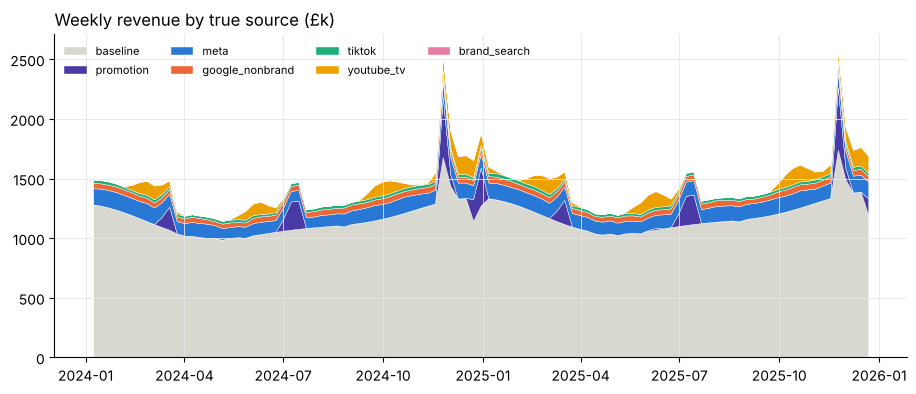

Media share of revenue: 16.7%


In [7]:
c = out["contributions"].assign(week=lambda d: d["date"].dt.to_period("W").dt.start_time)
wk = c.groupby(["week", "component"])["revenue"].sum().unstack() / 1e3
order = ["baseline", "promotion", "meta", "google_nonbrand", "tiktok", "youtube_tv", "brand_search"]
wk = wk[order].iloc[1:-1]          # drop partial first/last weeks
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.stackplot(wk.index, wk.T.values, colors=[COLORS[k] for k in order], labels=order, edgecolor="white", linewidth=0.3)
ax.set_title("Weekly revenue by true source (£k)", loc="left")
ax.legend(frameon=False, ncol=4, loc="upper left", fontsize=8); plt.show()

share = c.groupby("component")["revenue"].sum()
print("Media share of revenue:", f"{share.drop(['baseline','promotion']).sum() / share.sum():.1%}")

## 5. Brand search: the mediator in action
Brand search spend tracks *other* media - so it correlates with sales even though its own effect is tiny. Any method that reads correlation as causation will over-credit it.

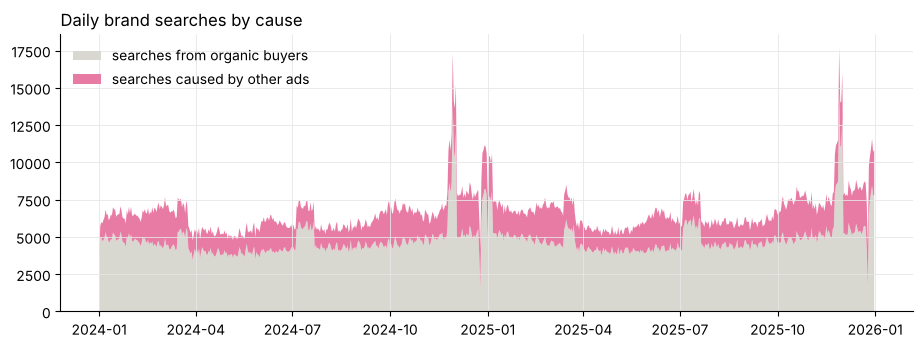

In [8]:
bs = out["brand_search_truth"].groupby("date")[["expected_queries_organic", "expected_queries_media"]].sum()
fig, ax = plt.subplots()
ax.stackplot(bs.index, bs["expected_queries_organic"], bs["expected_queries_media"],
             colors=["#d9d8d0", "#e87ba4"], labels=["searches from organic buyers", "searches caused by other ads"])
ax.set_title("Daily brand searches by cause", loc="left"); ax.legend(frameon=False, loc="upper left"); plt.show()

## 6. Write to the databases

In [9]:
media_all = pd.concat([media_daily, out["brand_search_media"].assign(cpm=np.nan, ctr=np.nan)], ignore_index=True)
nat_bs = (out["brand_search_media"].groupby(["date", "channel"], as_index=False)[["spend", "impressions", "clicks"]].sum())
national_all = pd.concat([national, nat_bs], ignore_index=True)

write_tables(ROOT / "truth/truth.duckdb", {
    "media_daily_clean": media_all,
    "media_national_clean": national_all,
    "channel_truth": out["channel_truth"],
    "contributions_daily": out["contributions"],
    "brand_search_truth": out["brand_search_truth"],
    "sales_truth": out["sales_truth"],
    "sales_daily_clean": out["sales_obs"],   # clean copy: notebook 03 corrupts observed from this
})
write_tables(ROOT / "data/observed.duckdb", {
    "media_daily": media_all.drop(columns=["cpm", "ctr"]),
    "media_national_daily": national_all,
    "sales_daily": out["sales_obs"],
})
print("written")

written


## 7. Sanity checks

In [10]:
con = duckdb.connect(str(ROOT / "data/observed.duckdb"), read_only=True)
con.sql("""select year(date) as year, sum(orders) as orders, round(sum(revenue)/1e6, 1) as revenue_m,
              round(sum(revenue)/sum(orders), 2) as aov
       from sales_daily group by 1 order by 1""").df()

,year,orders,revenue_m,aov
0,2024,1370614.0,74.1,54.03
1,2025,1438380.0,77.5,53.90


In [11]:
print("Smallest and largest regions - small ones will be noisy test markets")
con.sql("""select r.name, round(avg(s.orders), 1) as avg_daily_orders,
              round(stddev(s.orders)/avg(s.orders), 2) as coef_of_variation
       from sales_daily s join regions r using (region_id)
       group by 1 order by 2""").df().iloc[[0, 1, 2, -2, -1]]

Smallest and largest regions - small ones will be noisy test markets


,name,avg_daily_orders,coef_of_variation
0,Inverness,9.1,0.44
1,Dundee,20.2,0.35
2,Middlesbrough,22.6,0.34
38,Birmingham,156.7,0.32
39,London,1767.9,0.29


In [12]:
print("Observed tables (no truth columns should appear)")
con.sql("""select table_name, string_agg(column_name, ', ') as columns
       from information_schema.columns where table_catalog = 'observed' group by 1 order by 1""").df()

Observed tables (no truth columns should appear)


,table_name,columns
0,calendar,"date, year, day_of_week, day_of_year, iso_week..."
1,media_daily,"date, region_id, channel, spend, impressions, ..."
2,media_national_daily,"date, channel, spend, impressions, clicks"
3,promotions,"promo_name, region_id, start_date, end_date, d..."
4,regions,"region_id, name, nation, population"
5,sales_daily,"date, region_id, orders, revenue"


In [13]:
con.close()